<a href="https://colab.research.google.com/github/LordBrante/Analisis_ventas_retail/blob/graficos_retail/Proyecto_1_Marco_Brante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto I. Análisis y predicción de ventas-Part 1 (Core)




En este proyecto vamos a analizar el data set de retail de ventas. lo que ha sido solicitado es lo siguiente:

*  Carga y Preprocesamiento de Datos:

    Carga los datos del archivo CSV utilizando NumPy.
    Realiza un preprocesamiento básico para asegurarte de que los datos estén limpios y listos para su análisis.
   

*  Exploración de Datos:

    Calcula el total de ventas por categoría de producto.
    Calcula el promedio de ventas diarias por categoría de producto.
    Identifica las categorías de productos con mayores y menores ventas.
*   Manipulación de Datos:

    Filtra los datos para mostrar solo las ventas de una categoría de producto específica.
    Realiza operaciones de suma, resta, multiplicación y división en los datos para obtener estadísticas adicionales.

a continuacion se veran los distintos puntos solicitados



In [63]:
#Esto es para poder hacer la coneccion con mi google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Carga y analisis de los datos (informacion basica)

In [64]:
#importamos pandas
import pandas as pd
#esto es meramente para fines esteticos
separador = '=' * 100
#cargamos el dataset
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/retail_sales_dataset.csv')

Aqui veremos lo básico de la informacion del dataset de reail

In [65]:
print(separador)
print(f'RESUMEN DEL DATASET')
print(separador)
print(f'Informacion del dataset: \n')
df.info()

print(f'\nPrimeras 5 filas: \n\n {df.head()}\n')
print(f'Últimas 5 filas: \n\n {df.tail()}\n')
print(f'Descipcion del dataset: \n {df.describe()}\n')
print(f'Cantidad de elementos duplicados:\n\n {df.duplicated()}\n')
print(f'Cantidad de elementos nulos:\n \n{df.isnull().sum()}\n')
print(f'Tipos de datos :\n \n {df.dtypes.to_string()}')
print(separador)

RESUMEN DEL DATASET
Informacion del dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Primeras 5 filas: 

    Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003   

podemos ver que no existen ni datos duplicados ni datos nulos, eso es bueno para el estudio.
Sin embargo la columna Date es tipo object, debemos convertirla a datetime


In [66]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
print(f'Tipos de dato en Date :\n \n {df['Date'].dtypes}')

Tipos de dato en Date :
 
 datetime64[ns]


Exploración de Datos

In [67]:
# Total de ventas por categoría
totales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print('Total de ventas por categoría ($): \n')
for cat, monto in totales.items():
    print(f'       {cat:<15}: $ {monto:>10,.2f}')

# Promedio de ventas por categoría
promedios = df.groupby('Product Category')['Total Amount'].mean().sort_values(ascending=False).round(2)
print('\nPromedio de venta por transacción y categoría ($): \n')
for cat, prom in promedios.items():
    print(f'       {cat:<15}: $ {prom:>10,.2f}')

# Mayor y menor venta
print(f'\nCategoría con MAYOR venta total : \n{totales.idxmax()}  ($ {totales.max():,.2f})')
print(f'\nCategoría con MENOR venta total : \n{totales.idxmin()}  ($ {totales.min():,.2f})')

# Tabla resumen completa
print('\nResumen completo por categoría: \n')
resumen = df.groupby('Product Category').agg(
        Transacciones     = ('Transaction ID', 'count'),
        Unidades_vendidas = ('Quantity',        'sum'),
        Ingreso_total     = ('Total Amount',    'sum'),
        Ticket_promedio   = ('Total Amount',    'mean'),
        Precio_unitario   = ('Price per Unit',  'mean'),
        Edad_promedio     = ('Age',             'mean'),
    ).round(2)

resumen['Participacion_%'] = (
        resumen['Ingreso_total'] / resumen['Ingreso_total'].sum() * 100).round(1)
print(resumen.sort_values('Ingreso_total', ascending=False))

Total de ventas por categoría ($): 

       Electronics    : $ 156,905.00
       Clothing       : $ 155,580.00
       Beauty         : $ 143,515.00

Promedio de venta por transacción y categoría ($): 

       Beauty         : $     467.48
       Electronics    : $     458.79
       Clothing       : $     443.25

Categoría con MAYOR venta total : 
Electronics  ($ 156,905.00)

Categoría con MENOR venta total : 
Beauty  ($ 143,515.00)

Resumen completo por categoría: 

                  Transacciones  Unidades_vendidas  Ingreso_total  \
Product Category                                                    
Electronics                 342                849         156905   
Clothing                    351                894         155580   
Beauty                      307                771         143515   

                  Ticket_promedio  Precio_unitario  Edad_promedio  \
Product Category                                                    
Electronics                458.79           1

Manipulación y Operaciones Aritméticas

In [68]:
#Para comodidad de los calculos cree esta funcion para ver las estadisticas adicionales sobre la columna 'Electronics'

def estadisticas_adicionales(df_filtrado, categoria):
    # Cálculos adicionales sobre los datos filtrados
    suma_cantidades  = df_filtrado['Quantity'].sum()                         # SUMA
    rango_precios    = (df_filtrado['Price per Unit'].max()
                       - df_filtrado['Price per Unit'].min())                 # RESTA
    ingreso_total    = (df_filtrado['Quantity']
                        * df_filtrado['Price per Unit']).sum()               # MULTIPLICACIÓN
    venta_por_unidad = ingreso_total / suma_cantidades                       # DIVISIÓN

    return {
        'categoria'        : categoria,
        'transacciones'    : len(df_filtrado),
        'suma_cantidades'  : suma_cantidades,
        'precio_promedio'  : df_filtrado['Price per Unit'].mean(),
        'precio_max'       : df_filtrado['Price per Unit'].max(),
        'precio_min'       : df_filtrado['Price per Unit'].min(),
        'rango_precios'    : rango_precios,
        'ingreso_total'    : ingreso_total,
        'venta_por_unidad' : venta_por_unidad,
    }

In [69]:
df_filtrado = df[df['Product Category'] == 'Electronics'].copy().reset_index(drop=True)

print(f"  Filtrando por categoría: 'Electronics'")
print(f'  Transacciones encontradas: {len(df_filtrado)}')
print(f'\n  Primeras 5 filas filtradas:')
print(df_filtrado[['Transaction ID', 'Date', 'Gender', 'Age',
                    'Quantity', 'Price per Unit', 'Total Amount']].head().to_string(index=False))

stats = estadisticas_adicionales(df_filtrado, 'Electronics')
print(f"\n  Operaciones aritméticas sobre 'Electronics':\n")
print(f"    • Transacciones           : {stats['transacciones']}")
print(f"    • Suma de unidades        : {stats['suma_cantidades']}  [SUMA]")
print(f"    • Precio promedio unitario: $ {stats['precio_promedio']:,.2f}")
print(f"    • Precio máx − mín        : $ {stats['precio_max']} − $ {stats['precio_min']}"
      f" = $ {stats['rango_precios']:,.2f}  [RESTA]")
print(f"    • Ingreso total           : $ {stats['ingreso_total']:,.2f}  [MULTIPLICACIÓN Cantidad × Precio]")
print(f"    • Venta promedio/unidad   : $ {stats['venta_por_unidad']:,.2f}  [DIVISIÓN ingreso / unidades]")

  Filtrando por categoría: 'Electronics'
  Transacciones encontradas: 342

  Primeras 5 filas filtradas:
 Transaction ID       Date Gender  Age  Quantity  Price per Unit  Total Amount
              3 2023-01-13   Male   50         1              30            30
              8 2023-02-22   Male   30         4              25           100
              9 2023-12-13   Male   63         2             300           600
             13 2023-08-05   Male   22         3             500          1500
             15 2023-01-16 Female   42         4             500          2000

  Operaciones aritméticas sobre 'Electronics':

    • Transacciones           : 342
    • Suma de unidades        : 849  [SUMA]
    • Precio promedio unitario: $ 181.90
    • Precio máx − mín        : $ 500 − $ 25 = $ 475.00  [RESTA]
    • Ingreso total           : $ 156,905.00  [MULTIPLICACIÓN Cantidad × Precio]
    • Venta promedio/unidad   : $ 184.81  [DIVISIÓN ingreso / unidades]


Análisis Adicional (fechas, género, edad)

In [70]:
def analisis_adicional(df):
    # Análisis según el mes,usaremos datetime
    df = df.copy()
    df['Mes']     = df['Date'].dt.month_name()
    df['Mes_num'] = df['Date'].dt.month
    ventas_mes = (
        df.groupby(['Mes_num', 'Mes'])['Total Amount']
        .sum()
        .reset_index()
        .sort_values('Mes_num')
        .set_index('Mes')['Total Amount']
    )

    # Ventas por género
    ventas_genero = (
        df.groupby('Gender')['Total Amount']
        .agg(['sum', 'mean', 'count'])
        .rename(columns={'sum': 'Total', 'mean': 'Promedio', 'count': 'Transacciones'})
        .round(2)
    )

    # Ventas por rango etario
    bins   = [17, 25, 35, 45, 55, 65]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
    df['Rango_edad'] = pd.cut(df['Age'], bins=bins, labels=labels)
    ventas_edad = (
        df.groupby('Rango_edad', observed=True)['Total Amount']
        .sum()
        .sort_values(ascending=False)
    )

    return ventas_mes, ventas_genero, ventas_edad

In [71]:
ventas_mes, ventas_genero, ventas_edad = analisis_adicional(df)

print('Ventas totales por mes ($): \n')
for mes, monto in ventas_mes.items():
    barra = '█' * int(monto / 5000)
    print(f'    {mes:<12}: $ {monto:>8,.2f}  {barra}')

print('\nVentas por género: \n')
print(ventas_genero.to_string())

print('\nVentas totales por rango etario ($):\n')
for rango, monto in ventas_edad.items():
    print(f'    {rango}: $ {monto:>10,.2f}')

Ventas totales por mes ($): 

    January     : $ 36,980.00  ███████
    February    : $ 44,060.00  ████████
    March       : $ 28,990.00  █████
    April       : $ 33,870.00  ██████
    May         : $ 53,150.00  ██████████
    June        : $ 36,715.00  ███████
    July        : $ 35,465.00  ███████
    August      : $ 36,960.00  ███████
    September   : $ 23,620.00  ████
    October     : $ 46,580.00  █████████
    November    : $ 34,920.00  ██████
    December    : $ 44,690.00  ████████

Ventas por género: 

         Total  Promedio  Transacciones
Gender                                 
Female  232840    456.55            510
Male    223160    455.43            490

Ventas totales por rango etario ($):

    46-55: $ 100,690.00
    26-35: $  98,480.00
    36-45: $  91,870.00
    18-25: $  84,550.00
    56-65: $  80,410.00


**Resumen — Parte 1**

In [72]:
total_ingresos = df['Total Amount'].sum()

print(f'  Período analizado  : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Total transacciones: {len(df):,}')
print(f'  Clientes únicos    : {df["Customer ID"].nunique():,}')
print(f'  Categorías         : {", ".join(df["Product Category"].unique())}')
print(f'  Ingreso total      : $ {total_ingresos:,.2f}')
print(f'  Ticket promedio    : $ {df["Total Amount"].mean():,.2f}')
print(f'  Mediana de ventas  : $ {df["Total Amount"].median():,.2f}')
print(f'  Categoría estrella : {totales.idxmax()}  ($ {totales.max():,.2f}) — {totales.max()/total_ingresos*100:.1f}% del total)')
print('\n  ✓ Parte 1 completada exitosamente.')

  Período analizado  : 2023-01-01 → 2024-01-01
  Total transacciones: 1,000
  Clientes únicos    : 1,000
  Categorías         : Beauty, Clothing, Electronics
  Ingreso total      : $ 456,000.00
  Ticket promedio    : $ 456.00
  Mediana de ventas  : $ 135.00
  Categoría estrella : Electronics  ($ 156,905.00) — 34.4% del total)

  ✓ Parte 1 completada exitosamente.


#Proyecto I- Parte 2 (Core)— Análisis Exploratorio con Pandas


 Instrucciones para la Parte 2

1. Exploración Inicial de los Datos
- Muestra las **últimas 5 filas** del DataFrame.
- Utiliza el método **`info()`** para obtener información general sobre el DataFrame, incluyendo el número de entradas, nombres de las columnas, tipos de datos y memoria utilizada.
- Genera **estadísticas descriptivas** del DataFrame utilizando el método **`describe()`**.

2. Inspección de los Datos
- Inspecciona los **tipos de datos** de cada columna utilizando el atributo **`dtypes`**.
- Cuenta los valores únicos en la columna **Producto** utilizando el método **`value_counts()`**.
- Muestra todos los valores únicos en la columna **Tienda** utilizando el método **`unique()`**.
3. Filtrado de Datos
- Filtra el DataFrame para mostrar solo las filas donde las **ventas (Ventas)** sean **mayores a 50**.
- Filtra el DataFrame para mostrar solo las filas donde el **precio (Precio)** sea **menor a 0.5**.
- Utilizando el método **`query()`**, filtra el DataFrame para mostrar las filas donde el producto sea **Manzanas** y las ventas sean **mayores a 30**.

4. Slicing de Datos
- Selecciona y muestra solo las columnas **Producto** y **Ventas** del DataFrame.
- Utilizando **`loc[]`**, selecciona y muestra las filas de la **5 a la 10** (inclusive) y las columnas **Producto** y **Tienda**.
- Utilizando **`iloc[]`**, selecciona y muestra las **primeras 5 filas** y las **primeras 3 columnas** del DataFrame.

Ya que esta es la continuacion de la parte 1, la cual tambien la hice con Pandas, no es necesario volver a cargar el dataset. De todas maneras por temas de buenas costumbres volvere a realizar un analisis preliminar del dataset


In [73]:
print(separador)
print(f'RESUMEN DEL DATASET')
print(separador)
print(f'Informacion del dataset: \n')
df.info()

print(f'\nPrimeras 10 filas: \n\n {df.head(10)}\n')
print(f'Últimas 5 filas: \n\n {df.tail()}\n')
print(f'Descipcion del dataset: \n \n{df.describe().round(2)}\n')
print(f'Cantidad de elementos duplicados:\n\n {df.duplicated()}\n')
print(f'Cantidad de elementos nulos:\n \n{df.isnull().sum()}\n')
print(f'Tipos de datos :\n \n {df.dtypes.to_string()}')
print(separador)

RESUMEN DEL DATASET
Informacion del dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB

Primeras 10 filas: 

    Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1            

Inspección de Datos

In [74]:
# value_counts() sobre 'Product Category'
print('  Conteo de valores únicos por Product Category — value_counts():\n')
print(df['Product Category'].value_counts().to_string())

  Conteo de valores únicos por Product Category — value_counts():

Product Category
Clothing       351
Electronics    342
Beauty         307


Por el listado de las columnas que pudimos obtener arriba, no existe una columna 'Tienda' o similar, asi que usaremos 'Gender'(genero)
¿por que?

| Característica | `Tienda` (columna deseada) | `Gender` (nuestro dataset) |
|---|---|---|
| Tipo de dato | `object` / string | `object` / string |
| Valores posibles | pocos y fijos | pocos y fijos (Male / Female) |
| Propósito | agrupar / segmentar | agrupar / segmentar |
| `unique()` tiene sentido | ✓ | ✓ |

Podemos notar que ambas columnas se parecen y 'Gender' cumpliria con el objetivo a evaluar

*Nota: aprendi de la IA a escribir de esta forma en un markdown

In [75]:
# unique() sobre 'Gender'
generos = df['Gender'].unique()
print(f'  Valores únicos en Gender — unique():')
print(f'  {generos}')

  Valores únicos en Gender — unique():
  ['Male' 'Female']


Filtrado de Datos

In [76]:
#Total Amount > 500  (equivalente a: Ventas > 50)
filtro_ventas_altas = df[df['Total Amount'] > 500]
print(f'Filas donde Total Amount > 500:')
print(f'\nRegistros encontrados: {len(filtro_ventas_altas)}\n')
filtro_ventas_altas[['Transaction ID', 'Product Category',
                      'Quantity', 'Price per Unit', 'Total Amount']].head(10)

Filas donde Total Amount > 500:

Registros encontrados: 299



,Transaction ID,Product Category,Quantity,Price per Unit,Total Amount
1,2,Clothing,2,500,1000
8,9,Electronics,2,300,600
12,13,Electronics,3,500,1500
14,15,Electronics,4,500,2000
15,16,Clothing,3,500,1500
19,20,Clothing,3,300,900
25,26,Electronics,2,500,1000
29,30,Beauty,3,300,900
30,31,Electronics,4,300,1200
34,35,Beauty,3,300,900


In [77]:
#Price per Unit < 50  (equivalente a: Precio < 0.5)
filtro_precio_bajo = df[df['Price per Unit'] < 50]
print(f'Filas donde Price per Unit < 50:\n')
print(f'Registros encontrados: {len(filtro_precio_bajo)}\n')
filtro_precio_bajo[['Transaction ID', 'Product Category',
                     'Price per Unit', 'Total Amount']].head(10)

Filas donde Price per Unit < 50:

Registros encontrados: 393



,Transaction ID,Product Category,Price per Unit,Total Amount
2,3,Electronics,30,30
5,6,Beauty,30,30
6,7,Clothing,25,50
7,8,Electronics,25,100
11,12,Beauty,25,75
13,14,Clothing,30,120
16,17,Clothing,25,100
17,18,Electronics,25,50
18,19,Clothing,25,50
22,23,Clothing,30,120


In [78]:
#Se hizo el cambio porque no existe ningun producto Manzanas en este dataset, se usa Electronics para seguir con la consistencia de la Parte 1
filtro_query = df.query("`Product Category` == 'Electronics' and `Total Amount` > 300")
print(f'query() — Electronics AND Total Amount > 300:\n')
print(f'Registros encontrados: {len(filtro_query)}\n')
filtro_query[['Transaction ID', 'Date', 'Gender', 'Age',
              'Quantity', 'Price per Unit', 'Total Amount']]

query() — Electronics AND Total Amount > 300:

Registros encontrados: 117



,Transaction ID,Date,Gender,Age,Quantity,Price per Unit,Total Amount
8,9,2023-12-13,Male,63,2,300,600
12,13,2023-08-05,Male,22,3,500,1500
14,15,2023-01-16,Female,42,4,500,2000
25,26,2023-10-07,Female,28,2,500,1000
30,31,2023-05-23,Male,44,4,300,1200
...,...,...,...,...,...,...,...
926,927,2023-06-24,Male,43,4,500,2000
945,946,2023-05-08,Male,62,4,500,2000
953,954,2023-09-25,Female,50,3,300,900
965,966,2023-02-20,Male,60,2,500,1000


Slicing de Datos

In [79]:
#Selección de columnas: Product Category y Total Amount
#(equivalente a: Producto y Ventas)
print('Columnas Product Category y Total Amount (primeras 10 filas):\n')
df[['Product Category', 'Total Amount']].head(10)

Columnas Product Category y Total Amount (primeras 10 filas):



,Product Category,Total Amount
0,Beauty,150
1,Clothing,1000
2,Electronics,30
3,Clothing,500
4,Beauty,100
5,Beauty,30
6,Clothing,50
7,Electronics,100
8,Electronics,600
9,Clothing,200


In [80]:
# uso de loc[]
# columnas Product Category y Gender
print('loc[] — filas 4 a 9, columnas Product Category y Gender:\n')
df.loc[4:9, ['Product Category', 'Gender']]

loc[] — filas 4 a 9, columnas Product Category y Gender:



,Product Category,Gender
4,Beauty,Male
5,Beauty,Female
6,Clothing,Male
7,Electronics,Male
8,Electronics,Male
9,Clothing,Female


In [81]:
#uso de iloc[]
#(Transaction ID, Date, Customer ID)
print('iloc[] — primeras 5 filas y primeras 3 columnas: \n')
df.iloc[:5, :3]

iloc[] — primeras 5 filas y primeras 3 columnas: 



,Transaction ID,Date,Customer ID
0,1,2023-11-24,CUST001
1,2,2023-02-27,CUST002
2,3,2023-01-13,CUST003
3,4,2023-05-21,CUST004
4,5,2023-05-06,CUST005


Resumen Parte 2

In [82]:
print(f'  Dataset            : retail_sales_dataset.csv')
print(f'  Total registros    : {len(df):,}')
print(f'  Columnas           : {len(df.columns)}  {", ".join(df.columns)}')
print(f'  Categorías únicas  : {df["Product Category"].nunique()}  '
      f'({", ".join(df["Product Category"].unique())})')
print(f'  Géneros únicos     : {df["Gender"].nunique()}  '
      f'({", ".join(df["Gender"].unique())})')
print(f'  Rango de fechas    : {df["Date"].min().date()} -> {df["Date"].max().date()}')
print(f'  Total Amount máx   : $ {df["Total Amount"].max():,.2f}')
print(f'  Total Amount mín   : $ {df["Total Amount"].min():,.2f}')
print(f'  Price per Unit máx : $ {df["Price per Unit"].max():,.2f}')
print(f'  Price per Unit mín : $ {df["Price per Unit"].min():,.2f}')
print('\nParte 2 completada exitosamente.')

  Dataset            : retail_sales_dataset.csv
  Total registros    : 1,000
  Columnas           : 9  Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, Total Amount
  Categorías únicas  : 3  (Beauty, Clothing, Electronics)
  Géneros únicos     : 2  (Male, Female)
  Rango de fechas    : 2023-01-01 -> 2024-01-01
  Total Amount máx   : $ 2,000.00
  Total Amount mín   : $ 25.00
  Price per Unit máx : $ 500.00
  Price per Unit mín : $ 25.00

Parte 2 completada exitosamente.


#Proyecto I- Parte 3 (Core)— Análisis y Predicción de Ventas en una Tienda de Retail

Para esta tercera parte tenemos las siguientes instrucciones:

Transformación de Datos

* Crea nuevas columnas:
      
  Basándonos en los datos existentes, crea nuevas columnas que sean útiles para el análisis. Por ejemplo, calcula el ingreso total por venta y normaliza las ventas.
* Clasifica los datos:

  Crea una columna que clasifique las ventas en categorías significativas (e.g., ‘Alta’, ‘Media’, ‘Baja’).

Agrupación y Agregación

* Agrupación por múltiples columnas:

  Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.
* Aplicar funciones de agregación:
  
  Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.

Análisis Personalizado con apply

* Función personalizada:
  
  Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.
* Ejemplo de uso avanzado:

  Calcula la desviación de cada venta respecto a la media de su grupo.
Documentación

* Comentarios claros:
  
   Documenta claramente cada paso del análisis, explicando qué se hizo y por qué se hizo.
* Código legible:
  
  Asegúrate de que el código sea legible y esté bien comentado.



In [83]:
#Primero volveremos a ver como estaba el dataset
print(separador)
print(f'RESUMEN DEL DATASET')
print(separador)
print(f'Informacion del dataset: \n')
df.info()

print(f'\nPrimeras 5 filas: \n\n {df.head()}\n')
print(f'Últimas 5 filas: \n\n {df.tail()}\n')
print(f'Descipcion del dataset: \n {df.describe()}\n')
print(f'Cantidad de elementos duplicados:\n\n {df.duplicated()}\n')
print(f'Cantidad de elementos nulos:\n \n{df.isnull().sum()}\n')
print(f'Tipos de datos :\n \n {df.dtypes.to_string()}')
print(separador)
#Esto viene desde la parte 1

RESUMEN DEL DATASET
Informacion del dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB

Primeras 5 filas: 

    Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1             

En nuestro Dataset podemos ver que la columna 'Date' tiene un formato de fecha completo (yyyy-mm-dd), y si queremos agruparlos por la columna 'Date'se van a generar muchos registros y sin entregar ninguna informacion real, una mejor propuesta es ver las ventas por mes o saber en que mes vendi mas.

Nombre_Mes sera otra columna que se relaciona con la de 'Mes' es simplemente para que el output sea legible (Enero en vez de 1).

In [84]:
#Estas columnas son para mas exactitud en el calulo de tiempo
df['Mes']        = df['Date'].dt.month
df['Nombre_Mes'] = df['Date'].dt.month_name()

Y siguiendo el mismo analisis anterior, hay negocios que prefieren ver su comportamiento cada x cantidad de meses (Bimestre, Trimestre, Cuatrimestre o Semestre). Asi que decidi hacerlo en 4 Trimestres para poder analizar mejor el comportamiento de las ventas.

In [85]:
df['Trimestre']  = df['Date'].dt.quarter.map({
    1: 'Q1 (Ene-Mar)',
    2: 'Q2 (Abr-Jun)',
    3: 'Q3 (Jul-Sep)',
    4: 'Q4 (Oct-Dic)'
})


El dataset ya tiene Total Amount, pero ese valor viene del archivo CSV — alguien lo escribió o un sistema lo generó. La pregunta es: ¿es confiable?.

La columna que  llamaré 'Ingreso_calculado' viene de realizar el calculo Quantity × Price per Unit desde cero y compararlo con Total Amount. Es una forma de auditar la integridad del dato, lo que nos lleva a la segunda columna 'Diferencia_Monto'. Si Diferencia_Monto es 0 en todas las filas, el dato es consistente. Si hay filas con diferencia, hay un error en el origen que hay que investigar antes de analizar.

In [86]:
df['Ingreso_Calculado'] = df['Quantity'] * df['Price per Unit']

# Aquí esperamos que sea 0 en todos los casos.
df['Diferencia_Monto'] = df['Total Amount'] - df['Ingreso_Calculado']

Clasificacion de las ventas

    Clasificamos cada transacción en Alta, Media o Baja según
    el monto total. Los umbrales los definimos a partir de los
    percentiles 33 y 66 del dataset, para que la distribución
    entre categorías sea razonablemente equilibrada y no
    arbitraria.



In [87]:
p33 = df['Total Amount'].quantile(0.33)
p66 = df['Total Amount'].quantile(0.66)

def clasificar_venta(monto):
    if monto >= p66:
        return 'Alta'
    elif monto >= p33:
        return 'Media'
    else:
        return 'Baja'

df['Clasificacion_Venta'] = df['Total Amount'].apply(clasificar_venta)

print(f"\nClasificación de ventas (umbrales basados en percentiles):")
print(f"       Percentil 33 → $ {p33:,.2f}  (umbral Baja / Media)")
print(f"       Percentil 66 → $ {p66:,.2f}  (umbral Media / Alta)")
print(f"\nDistribución resultante:")
print(df['Clasificacion_Venta'].value_counts().to_string())


Clasificación de ventas (umbrales basados en percentiles):
       Percentil 33 → $ 90.00  (umbral Baja / Media)
       Percentil 66 → $ 500.00  (umbral Media / Alta)

Distribución resultante:
Clasificacion_Venta
Alta     350
Media    345
Baja     305


Estos números salieron de los datos mismos. El percentil 33 es el valor donde el 33% de las transacciones queda por debajo, y el 66 donde queda el 66%.

El hecho de que Alta y Media sean casi iguales y Baja sea apenas un poco menor indica que la distribución de ventas es bastante pareja, osea, no hay una concentración masiva en tickets bajos ni en tickets altos. Esto es una señal positiva: no hay dependencia exclusiva de pocas ventas grandes ni de muchísimas ventas pequeñas.

Seccion de Agrupacion y Agregacion

 Queremos saber si existe diferencia en el comportamiento de
compra entre hombres y mujeres dentro de cada categoría.
Usamos varias métricas a la vez para tener una imagen completa.

In [88]:
grupo_cat_genero = df.groupby(['Product Category', 'Gender'])['Total Amount'].agg(
    Transacciones = 'count',
    Ingreso_Total = 'sum',
    Promedio      = 'mean',
    Maximo        = 'max',
    Minimo        = 'min',
    Std           = 'std',
    Varianza      = 'var'
).round(2)

print(f"\nAgrupación por Categoría × Género:\n")
print(grupo_cat_genero.to_string())


Agrupación por Categoría × Género:

                         Transacciones  Ingreso_Total  Promedio  Maximo  Minimo     Std   Varianza
Product Category Gender                                                                           
Beauty           Female            166          74830    450.78    2000      25  538.74  290235.44
                 Male              141          68685    487.13    2000      25  592.90  351530.08
Clothing         Female            174          81275    467.10    2000      25  577.02  332948.03
                 Male              177          74305    419.80    2000      25  524.12  274697.83
Electronics      Female            170          76735    451.38    2000      25  548.64  301010.95
                 Male              172          80170    466.10    2000      25  587.13  344721.29



Ver cómo se comportan las ventas por categoría a lo largo
del año nos ayuda a detectar estacionalidad. Si Electronics
sube en Q4, por ejemplo, podría indicar efecto navideño.

In [89]:
grupo_cat_trimestre = df.groupby(['Product Category', 'Trimestre'])['Total Amount'].agg(
    Transacciones = 'count',
    Ingreso_Total = 'sum',
    Promedio      = 'mean'
).round(2)

print(f"\nAgrupación por Categoría × Trimestre:\n")
print(grupo_cat_trimestre.to_string())



Agrupación por Categoría × Trimestre:

                               Transacciones  Ingreso_Total  Promedio
Product Category Trimestre                                           
Beauty           Q1 (Ene-Mar)             73          38510    527.53
                 Q2 (Abr-Jun)             82          35350    431.10
                 Q3 (Jul-Sep)             71          32200    453.52
                 Q4 (Oct-Dic)             81          37455    462.41
Clothing         Q1 (Ene-Mar)             97          42750    440.72
                 Q2 (Abr-Jun)            101          41565    411.53
                 Q3 (Jul-Sep)             71          30680    432.11
                 Q4 (Oct-Dic)             82          40585    494.94
Electronics      Q1 (Ene-Mar)             66          28770    435.91
                 Q2 (Abr-Jun)             85          46820    550.82
                 Q3 (Jul-Sep)             89          33165    372.64
                 Q4 (Oct-Dic)            102      

De igual forma lo agruparemos mensualmente, para entrar en un detalle mas profundo ya que vimos los Trimestres

In [90]:
grupo_mensual = df.groupby(['Mes', 'Nombre_Mes'])['Total Amount'].agg(
    count = 'count',
    sum   = 'sum',
    mean  = 'mean',
    min   = 'min',
    max   = 'max',
    std   = 'std',
    var   = 'var'
).round(2).reset_index().sort_values('Mes').set_index('Nombre_Mes').drop(columns='Mes')

print(f"\nAgrupación mensual — todas las funciones de agregación:")
print(grupo_mensual.to_string())


Agrupación mensual — todas las funciones de agregación:
            count    sum    mean  min   max     std        var
Nombre_Mes                                                    
January        78  36980  474.10   25  2000  587.74  345439.44
February       85  44060  518.35   25  2000  617.27  381016.30
March          73  28990  397.12   25  2000  462.44  213854.80
April          86  33870  393.84   25  2000  536.22  287534.51
May           105  53150  506.19   25  2000  600.18  360220.44
June           77  36715  476.82   25  2000  550.68  303252.57
July           72  35465  492.57   25  2000  576.84  332743.66
August         94  36960  393.19   25  2000  509.93  260030.03
September      65  23620  363.38   25  2000  523.36  273901.65
October        96  46580  485.21   25  2000  608.96  370831.54
November       78  34920  447.69   25  2000  553.02  305825.77
December       91  44690  491.10   25  2000  555.31  308369.33


Para seguir analizando el dataset, veremos un analisis mas perrsonalizado usando apply()

 Para cada transacción calculamos cuánto se aleja del promedio
de su categoría. Esto nos dice si una venta fue excepcional
(positiva o negativamente) dentro de su propio contexto.
No tiene sentido comparar una venta de Electronics con una
de Beauty si sus precios son muy distintos.

In [91]:
media_por_categoria = df.groupby('Product Category')['Total Amount'].transform('mean')
df['Desviacion_vs_Media_Cat'] = (df['Total Amount'] - media_por_categoria).round(2)

print(f"\nDesviación de cada venta vs. media de su categoría:")
print(f"       (positivo = venta sobre el promedio, negativo = bajo el promedio)\n")
print(df[['Transaction ID', 'Product Category', 'Total Amount',
          'Desviacion_vs_Media_Cat']].head(10).to_string(index=False))

print(f"\nVentas más alejadas del promedio de su categoría (top 5 sobre):")
print(df.nlargest(5, 'Desviacion_vs_Media_Cat')
      [['Transaction ID', 'Product Category', 'Total Amount', 'Desviacion_vs_Media_Cat']]
      .to_string(index=False))

print(f"\nVentas más alejadas del promedio de su categoría (top 5 bajo):")
print(df.nsmallest(5, 'Desviacion_vs_Media_Cat')
      [['Transaction ID', 'Product Category', 'Total Amount', 'Desviacion_vs_Media_Cat']]
      .to_string(index=False))


Desviación de cada venta vs. media de su categoría:
       (positivo = venta sobre el promedio, negativo = bajo el promedio)

 Transaction ID Product Category  Total Amount  Desviacion_vs_Media_Cat
              1           Beauty           150                  -317.48
              2         Clothing          1000                   556.75
              3      Electronics            30                  -428.79
              4         Clothing           500                    56.75
              5           Beauty           100                  -367.48
              6           Beauty            30                  -437.48
              7         Clothing            50                  -393.25
              8      Electronics           100                  -358.79
              9      Electronics           600                   141.21
             10         Clothing           200                  -243.25

Ventas más alejadas del promedio de su categoría (top 5 sobre):
 Transaction ID 

Otra forma de usar el apply() seria ver como se comporta cada transaccion dentro de su categoria correspondiente, ya que no es lo mismo una venta "alta" en 'Beauty'(belleza) que en 'Electronics'(Electronicos)

In [92]:
def etiqueta_relativa(grupo):
    media = grupo['Total Amount'].mean()
    std   = grupo['Total Amount'].std()

    def etiquetar(monto):
        if monto > media + std:
            return 'Excepcional'
        elif monto > media:
            return 'Sobre promedio'
        elif monto > media - std:
            return 'Bajo promedio'
        else:
            return 'Muy bajo'

    grupo = grupo.copy()
    grupo['Rendimiento_Relativo'] = grupo['Total Amount'].apply(etiquetar)
    return grupo

df = df.groupby('Product Category', group_keys=False).apply(etiqueta_relativa)

print(f"\nEtiqueta de rendimiento relativo por categoría:")
print(df['Rendimiento_Relativo'].value_counts().to_string())

print(f"\nDistribución por categoría:")
print(df.groupby(['Product Category', 'Rendimiento_Relativo'])
      .size()
      .unstack(fill_value=0)
      .to_string())



Etiqueta de rendimiento relativo por categoría:
Rendimiento_Relativo
Bajo promedio     650
Sobre promedio    185
Excepcional       165

Distribución por categoría:
Rendimiento_Relativo  Bajo promedio  Excepcional  Sobre promedio
Product Category                                                
Beauty                          196           48              63
Clothing                        229           64              58
Electronics                     225           53              64


/tmp/ipykernel_2520/2623035655.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Product Category', group_keys=False).apply(etiqueta_relativa)


Encontre muy necesario agregar esta nota. No entendia lo que era ese Warning que me arrojo la celda anterior, asi que lo consulte con la Ia y esta fue su respuesta
>
**Nota sobre el DeprecationWarning**
>
> Al ejecutar esta celda puede aparecer el siguiente aviso:
> `DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated...`
>
> **¿Qué significa?**
> Es un aviso de los desarrolladores de Pandas informando que el comportamiento actual
> de `groupby().apply()` cambiará en versiones futuras. Hoy en día, cuando se usa
> `apply()` sobre un grupo, Pandas incluye automáticamente la columna de agrupación
> (`Product Category`) dentro del DataFrame que recibe la función personalizada.
> En versiones futuras esa columna será excluida por defecto.
>
> **¿Afecta el resultado?**
> No. El código funciona correctamente y el resultado es el esperado.
> Es únicamente un aviso preventivo, no un error.
>
> **¿Se puede corregir?**
> La solución oficial es agregar `include_groups=False` al `apply()`

Como ultimo analisis, me parecio prudente ver cuantas transacciones hizo un cliente y con cuanto gasto promedio.
La idea es identificar **clientes de alto valor** para poder entregarles beneficios y asi ganar su fidelidad.

In [93]:
gasto_promedio_global = df['Total Amount'].mean()
trans_promedio_global = df.groupby('Customer ID').size().mean()

resumen_clientes = df.groupby('Customer ID').agg(
    Transacciones  = ('Transaction ID', 'count'),
    Gasto_Total    = ('Total Amount',   'sum'),
    Gasto_Promedio = ('Total Amount',   'mean')
).round(2)

def calcular_score(row):
    score_gasto = row['Gasto_Total'] / (gasto_promedio_global * trans_promedio_global)
    score_freq  = row['Transacciones'] / trans_promedio_global
    return round((score_gasto + score_freq) / 2, 4)

resumen_clientes['Score_Valor'] = resumen_clientes.apply(calcular_score, axis=1)
resumen_clientes = resumen_clientes.sort_values('Score_Valor', ascending=False)

print(f"\nScore de valor por cliente (top 10):")
print(resumen_clientes.head(10).to_string())


Score de valor por cliente (top 10):
             Transacciones  Gasto_Total  Gasto_Promedio  Score_Valor
Customer ID                                                         
CUST015                  1         2000          2000.0        2.693
CUST412                  1         2000          2000.0        2.693
CUST970                  1         2000          2000.0        2.693
CUST547                  1         2000          2000.0        2.693
CUST281                  1         2000          2000.0        2.693
CUST416                  1         2000          2000.0        2.693
CUST420                  1         2000          2000.0        2.693
CUST927                  1         2000          2000.0        2.693
CUST447                  1         2000          2000.0        2.693
CUST342                  1         2000          2000.0        2.693


Resumen de la tercera parte del Proyecto 1

In [94]:
mejor_trimestre = df.groupby('Trimestre')['Total Amount'].sum().idxmax()
cat_mas_excepcional = (
    df[df['Rendimiento_Relativo'] == 'Excepcional']
    .groupby('Product Category').size().idxmax()
)
mejor_cliente = resumen_clientes['Score_Valor'].idxmax()

print(f"\n  Columnas nuevas creadas     : Mes, Nombre_Mes, Trimestre,")
print(f"                                Ingreso_Calculado, Diferencia_Monto,")
print(f"                                Venta_Normalizada, Clasificacion_Venta,")
print(f"                                Desviacion_vs_Media_Cat, Rendimiento_Relativo,")
print(f"  Agrupaciones realizadas     : Categoría×Género, Categoría×Trimestre,")
print(f"                                Categoría×Clasificación, Mensual completa")
print(f"  Trimestre con más ingresos  : {mejor_trimestre}")
print(f"  Categoría más 'Excepcional' : {cat_mas_excepcional}")
print(f"  Cliente de mayor valor      : {mejor_cliente}  "
      f"(Score: {resumen_clientes.loc[mejor_cliente, 'Score_Valor']})")


  Columnas nuevas creadas     : Mes, Nombre_Mes, Trimestre,
                                Ingreso_Calculado, Diferencia_Monto,
                                Venta_Normalizada, Clasificacion_Venta,
                                Desviacion_vs_Media_Cat, Rendimiento_Relativo,
  Agrupaciones realizadas     : Categoría×Género, Categoría×Trimestre,
                                Categoría×Clasificación, Mensual completa
  Trimestre con más ingresos  : Q4 (Oct-Dic)
  Categoría más 'Excepcional' : Clothing
  Cliente de mayor valor      : CUST015  (Score: 2.693)


#Proyecto I - Parte 4 (Core) - Análisis Exploratorio de Datos y Visualización

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.



Instrucciones

Continuar desde la Parte III
Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.
Análisis Descriptivo y Visualización
Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.
Generar un Pull Request en GitHub
Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.


In [95]:
#Ya que comenzaremos a graficar en esta parte del proyecto, pondre los imports del matplolib aqui
import matplotlib.pyplot as plt



como aprendi en los cores anteriores, es conveniente tener aparte un estilo "general"
para todos los gráficos, esta sección es para eso

In [96]:
plt.rcParams['figure.figsize']  = (10, 5)
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.labelsize']  = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

# Colores
colores_categorias = {
    'Beauty'     : 'red',
    'Clothing'   : 'blue',
    'Electronics': 'Green'
}

##Estadísticas Descriptivas
Antes de graficar debemos ver si existe algun dato muy disperso, pues esto afectaría el gráfico, se conocen como Outliers

In [97]:
#Caso columna Date
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')



Algo a considerar son las columnas con valores numéricos que serían claves para el negocio. Estas serían 'Age', 'Quantity', 'Price per Unit' y 'Total Amount'
Asi que debemos evaluarlas para que, de existir alguna desviación, no afecte negativamente al análisis mediante gráficos

In [98]:
colum_VIP_negocio = ['Age','Quantity', 'Price per Unit', 'Total Amount']
print("Estadísticas descriptivas")
print(df[colum_VIP_negocio].describe().round(2).to_string())

print("\nVentas totales por categoría: ")
print(df.groupby('Product Category')['Total Amount'].agg(['sum','mean','std']).round(2).to_string())


Estadísticas descriptivas
           Age  Quantity  Price per Unit  Total Amount
count  1000.00   1000.00         1000.00        1000.0
mean     41.39      2.51          179.89         456.0
std      13.68      1.13          189.68         560.0
min      18.00      1.00           25.00          25.0
25%      29.00      1.00           30.00          60.0
50%      42.00      3.00           50.00         135.0
75%      53.00      4.00          300.00         900.0
max      64.00      4.00          500.00        2000.0

Ventas totales por categoría: 
                     sum    mean     std
Product Category                        
Beauty            143515  467.48  563.61
Clothing          155580  443.25  550.70
Electronics       156905  458.79  567.54


Se puede apreciar que no hay mucha dispercion en los datos, no existe alguno que se escape mucho de la medición lo cual es un beneficio para nuestro análisis.

##Sección de Histogramas


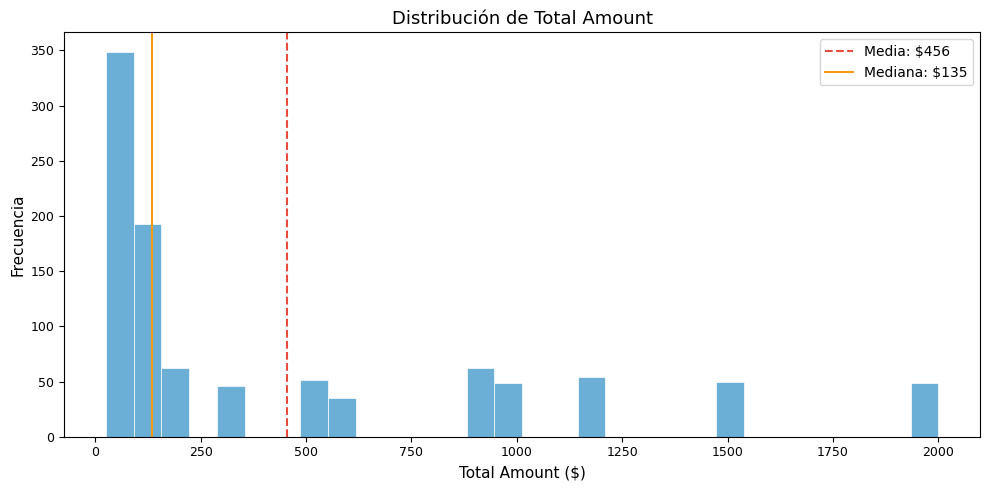

In [99]:
fig, ax = plt.subplots()

ax.hist(df['Total Amount'], bins=30, color='#6baed6', edgecolor='white', linewidth=0.5)

ax.axvline(df['Total Amount'].mean(),   color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f"Media: ${df['Total Amount'].mean():,.0f}")
ax.axvline(df['Total Amount'].median(), color='#f39c12', linestyle='-', linewidth=1.5,
           label=f"Mediana: ${df['Total Amount'].median():,.0f}")

ax.set_title('Distribución de Total Amount')
ax.set_xlabel('Total Amount ($)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

Este histograma ayuda a evaluar si las ventas (Total Amount) se concentraban en montos bajos, medios o altos.

Podemos ver que la distribución no es uniforme, la mayor cantidad de ventas esta ubicadas en los montos bajos, de hecho vemos que la Mediana esta fuertemente cargada a los precios bajos y hay una amplia diferencia con la Media.

Otro aspecto interesante es el comportamiento de algunas barras en montos específicos, como 500, 1000, 1200, 1500 y 2000. En lugar de disminuir de forma completamente gradual, aparecen grupos de transacciones concentradas en esos valores. Esto podría indicar la existencia de precios fijos, paquetes de productos o categorías de compra frecuentes en esos rangos, lo que también ayuda a explicar la alta variabilidad observada en los datos.


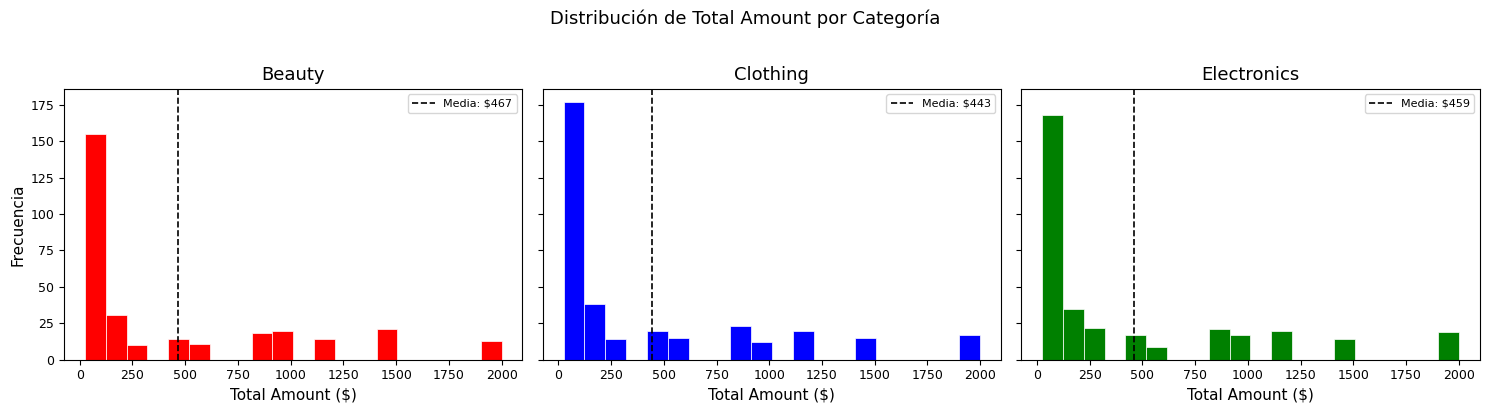

In [100]:
categorias = df['Product Category'].unique()
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, cat in zip(axes, categorias):
    datos = df[df['Product Category'] == cat]['Total Amount']
    ax.hist(datos, bins=20, color=colores_categorias[cat], edgecolor='white', linewidth=0.5)
    ax.axvline(datos.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Media: ${datos.mean():,.0f}')
    ax.set_title(cat)
    ax.set_xlabel('Total Amount ($)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Frecuencia')
fig.suptitle('Distribución de Total Amount por Categoría', fontsize=13, y=1.02)
plt.tight_layout()

Los 3 histogramas son bastante parecidos, podemos ver que la mayor concentracion de compras esta en los precios bajos.
La poca compra a la derecha es consistente independientemente de la categoría, lo que confirma que no es un fenómeno de un producto específico sino del comportamiento general de compra.

Diferencias entre categorías
* Beauty (rojo): la barra inicial es la más alta en términos relativos a su tamaño (casi 155 transacciones de bajo monto). Las barras dispersas en rangos altos son más pequeñas que en las otras categorías, sugiriendo que los productos de belleza de alto valor se venden con menos frecuencia.
* Clothing (azul): tiene la barra inicial más alta en términos absolutos (casi 175 transacciones), lo que indica que es la categoría con más compras de bajo monto. Sin embargo también tiene presencia en prácticamente todos los rangos de precio, lo que indica mayor variedad de productos.
* Electronics (verde): barra inicial alta (casi 165) pero con una caída más gradual en los rangos intermedios (250-500) comparado con las otras dos. Esto es coherente con la naturaleza de los productos electrónicos — hay más productos de precio medio-alto que en Beauty o Clothing.


Las medias de las tres categorías ($467, $443, $459) son casi idénticas, pero este gráfico muestra que esa similitud esconde distribuciones con formas distintas.

##Seccion Boxplots

/tmp/ipykernel_2520/491971098.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(datos_box, patch_artist=True, labels=categorias,


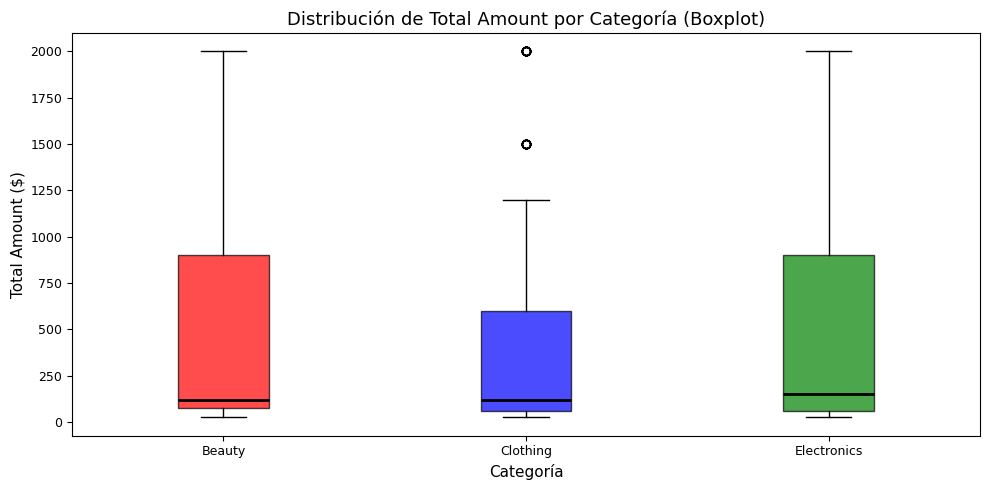

In [101]:
fig, ax = plt.subplots()

datos_box  = [df[df['Product Category'] == cat]['Total Amount'] for cat in categorias]
colores_box = [colores_categorias[cat] for cat in categorias]

box = ax.boxplot(datos_box, patch_artist=True, labels=categorias,
                medianprops=dict(color='black', linewidth=2))


for patch, color in zip(box['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


ax.set_title('Distribución de Total Amount por Categoría (Boxplot)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

Medianas similares y bajas en las 3 categorías
La línea negra dentro de cada caja está en un valor similar y bajo para las tres categorías. Esto confirma que el cliente frecuente gasta poco.

Adicional tenemos diferencias en el IQR

Beauty y Electronics tienen cajas muy grandes, lo que indica alta variabilidad en el 50% central de sus transacciones. Hay mucha diferencia entre lo que gasta un cliente típico bajo y uno típico alto dentro de estas categorías.
Clothing tiene la caja más pequeña, indicando que el 50% central de sus ventas es más consistente y predecible que las otras dos.

Lo más destacable son los dos outliers en Clothing, dos puntos en $1500 y $2000 aproximadamente.Esto significa que esas transacciones están tan por encima del comportamiento normal de la categoría que el criterio IQR las detecta como atípicas



##Seccion Gráficos de Linea

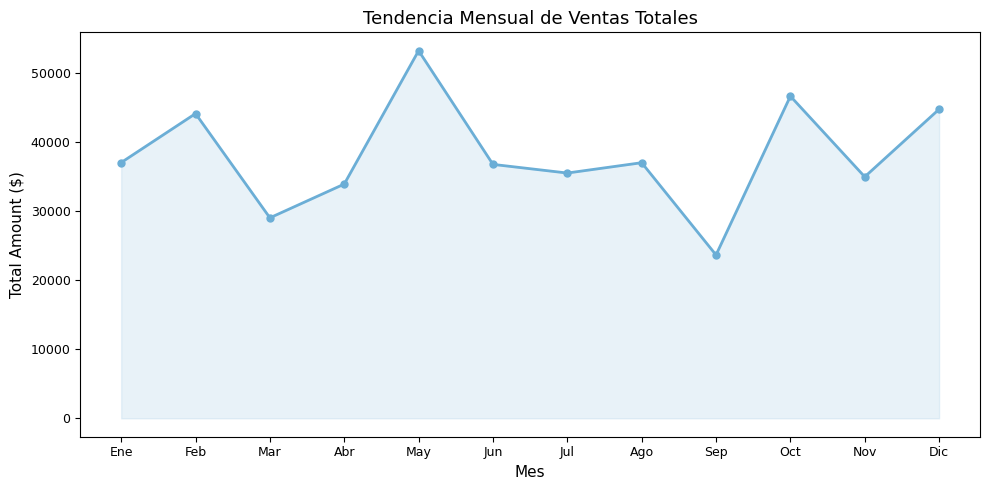

In [102]:
#Tendencia Mensual vs Total Amount

df['Mes'] = df['Date'].dt.month
ventas_mes = df.groupby('Mes')['Total Amount'].sum()

fig, ax = plt.subplots()

ax.plot(ventas_mes.index, ventas_mes.values,
        color='#6baed6', linewidth=2, marker='o', markersize=5)

ax.fill_between(ventas_mes.index, ventas_mes.values, alpha=0.15, color='#6baed6')

ax.set_title('Tendencia Mensual de Ventas Totales')
ax.set_xlabel('Mes')
ax.set_ylabel('Total Amount ($)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

Este gráfico seria como un resumen de las 3 cateogiras, y podemos ver una clara tendenci:
* Mayo es el mes peak del año con casi 53.000 en ventas totales, liderado principalmente por Electronics
* Septiembre es el mes más bajo con casi 24.000, una caída marcada respecto al resto del año
* El año tiene dos momentos fuertes: Mayo y el trimestre Oct-Nov-Dic con recuperación hacia fin de año

Nota: El área sombreada ayuda a visualizar el volumen acumulado. La empresa genera ventas relativamente estables entre 30.000 y 45.000 la mayor parte del año, con Septiembre como excepción clara a la baja y Mayo como excepción al alza. Esto significa que a pesar de la caída que tienen en Septiembre, se recuperan con lo ganado en el mes de Mayo

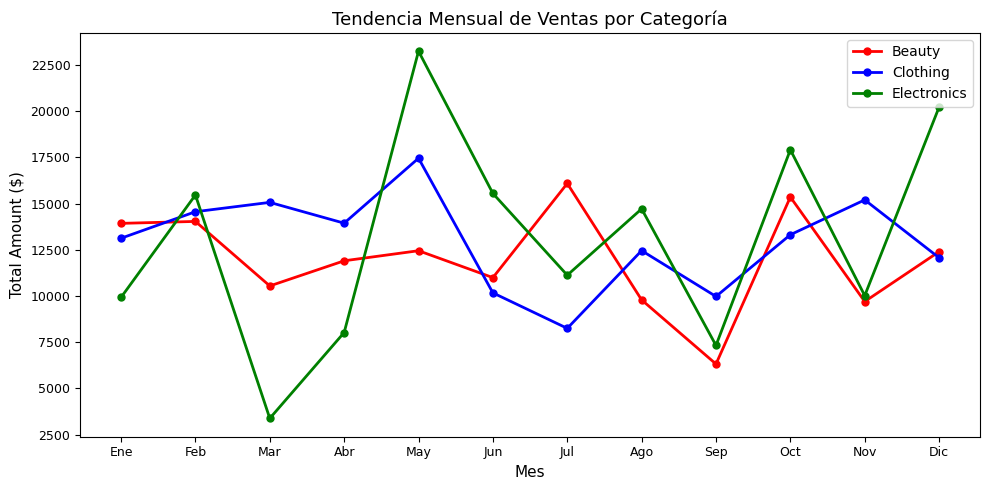

In [103]:
#Tendencia mensual vs categoria
ventas_mes_cat = df.groupby(['Mes', 'Product Category'])['Total Amount'].sum().unstack()

fig, ax = plt.subplots()

for cat in ventas_mes_cat.columns:
    ax.plot(ventas_mes_cat.index, ventas_mes_cat[cat],
            color=colores_categorias[cat], linewidth=2, marker='o',
            markersize=5, label=cat)

ax.set_title('Tendencia Mensual de Ventas por Categoría')
ax.set_xlabel('Mes')
ax.set_ylabel('Total Amount ($)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
ax.legend()
plt.tight_layout()
plt.show()

Lo más llamativo es el comportamiento de Electronics (verde) — es la línea más volátil de las tres, con caídas y subidas extremas:

* Mínimo absoluto en Marzo, el valor más bajo de todo el gráfico
* Máximo absoluto en Mayo, el valor más alto de todo el gráfico
* Otra subida fuerte en Octubre  y Diciembre

Esto sugiere que Electronics es una categoría estacional — muy sensible a fechas específicas (Mayo podría coincidir con promociones, Diciembre con fiestas).

Beauty (rosado) y Clothing (azul) son mucho más estables a lo largo del año, manteniéndose en un rango de 8.000 a 17.000 sin valores extremos. Clothing tiene su mejor momento en Mayo también, mientras que Beauty destaca en Octubre.

##Seccion Gráficos de Dispersión

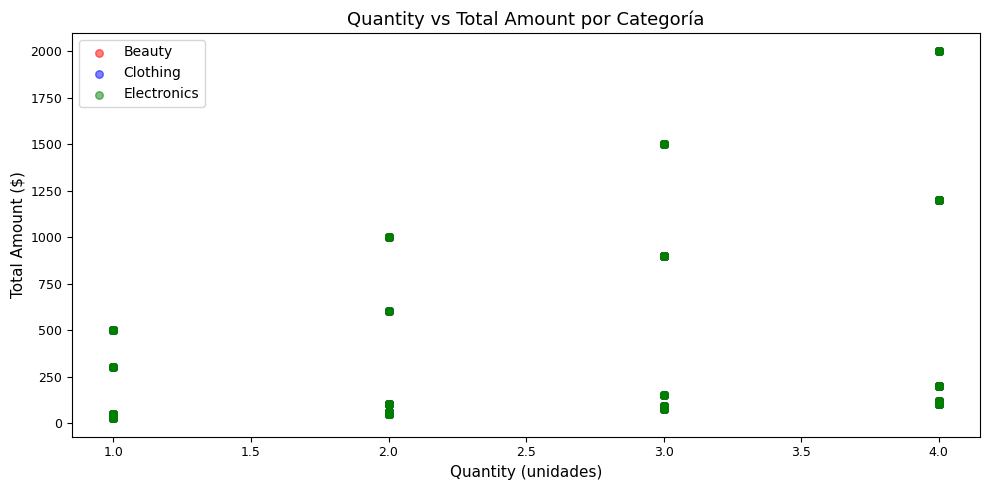

In [104]:
#Quantity vs Total Amount (Categoria)

fig, ax = plt.subplots()

for cat in categorias:
    sub = df[df['Product Category'] == cat]
    ax.scatter(sub['Quantity'], sub['Total Amount'],
               color=colores_categorias[cat], alpha=0.5, s=30, label=cat)

ax.set_title('Quantity vs Total Amount por Categoría')
ax.set_xlabel('Quantity (unidades)')
ax.set_ylabel('Total Amount ($)')
ax.legend()
plt.tight_layout()
plt.show()

Quiero dejar esta primera ejecucion del grafico de dispercion presente para que se note la mejora.
Consulte con la IA el problema de que solo se veia el verde, y debido a que presentan valores similares estos quedaban superpuestos, por lo que averiguando e investigando llegue a esta nueva version que se ejecutara a continuacion

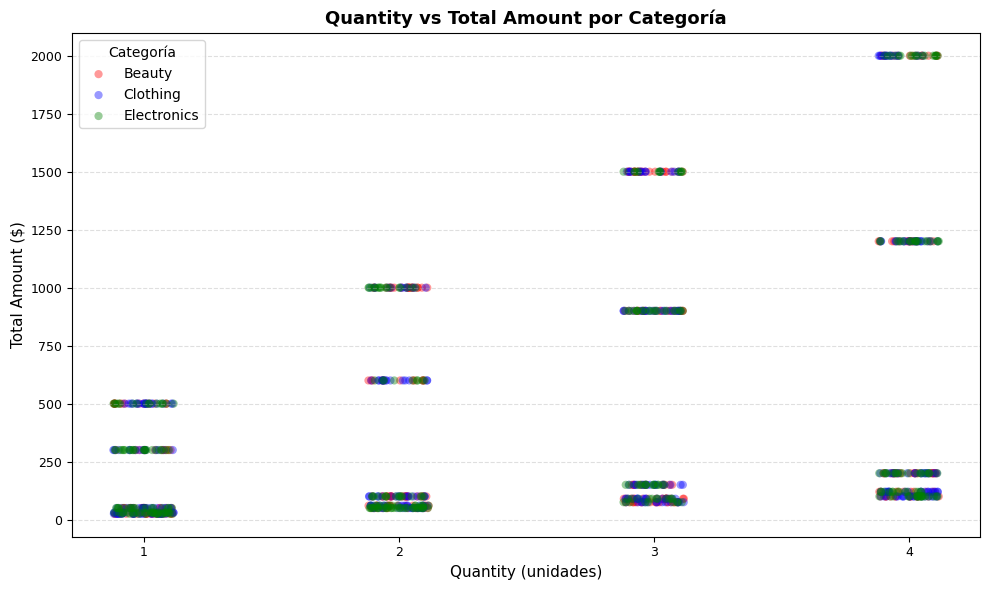

In [105]:
import numpy as np
fig, ax = plt.subplots(figsize=(10, 6))

for cat, color in colores_categorias.items():
    subset = df[df['Product Category'] == cat]

    # Jitter: desplazamiento aleatorio pequeño en X para separar puntos superpuestos
    np.random.seed(42)
    jitter = np.random.uniform(-0.12, 0.12, size=len(subset))

    ax.scatter(subset['Quantity'] + jitter,
               subset['Total Amount'],
               label=cat,
               color=color,
               alpha=0.4,      # transparencia para ver superposiciones
               s=35,           # tamaño del punto
               edgecolors='none')

ax.set_title('Quantity vs Total Amount por Categoría', fontweight='bold')
ax.set_xlabel('Quantity (unidades)')
ax.set_ylabel('Total Amount ($)')
ax.set_xticks([1, 2, 3, 4])   # solo los valores reales que existen
ax.legend(title='Categoría')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

El gráfico confirma algo importante: el Total Amount no crece de forma continua con la cantidad, sino que toma valores fijos y discretos (25, 50, 100, 300, 500, 600, 900, 1000, 1200, 1500, 2000). Esto refuerza lo que nos enseñaron los histogramas, el precio es predefinido y no una cantidad variable.

Hay una tendencia positiva clara respecto a la relacion entre Relación Quantity y el Total Amount:

* Con 1 unidad los montos se concentran en la franja baja (25-500)
* Con 2 unidades aparecen montos intermedios (60-1000)
* Con 3 unidades se alcanzan montos medios-altos (90-1500)
* Con 4 unidades se llega a los montos más altos (100-2000)

Eso si, no es una relacion perfecta porque hay montos bajos aun con 4 unidades, esto muestra que el precio unitario varia mucho segun el producto comprado.

Las tres categorías  están presentes en prácticamente todos los rangos de cantidad y monto, sin que ninguna domine claramente una zona específica del gráfico. Esto es consistente con las medias similares que vimos en el boxplot.

La variable que más explica el Total Amount no es la cantidad sino el precio unitario del producto porque comprar 1 unidad cara puede generar más ingreso que comprar 4 unidades baratas. Para un análisis más profundo convendría incorporar Price per Unit como tercera variable en este gráfico.

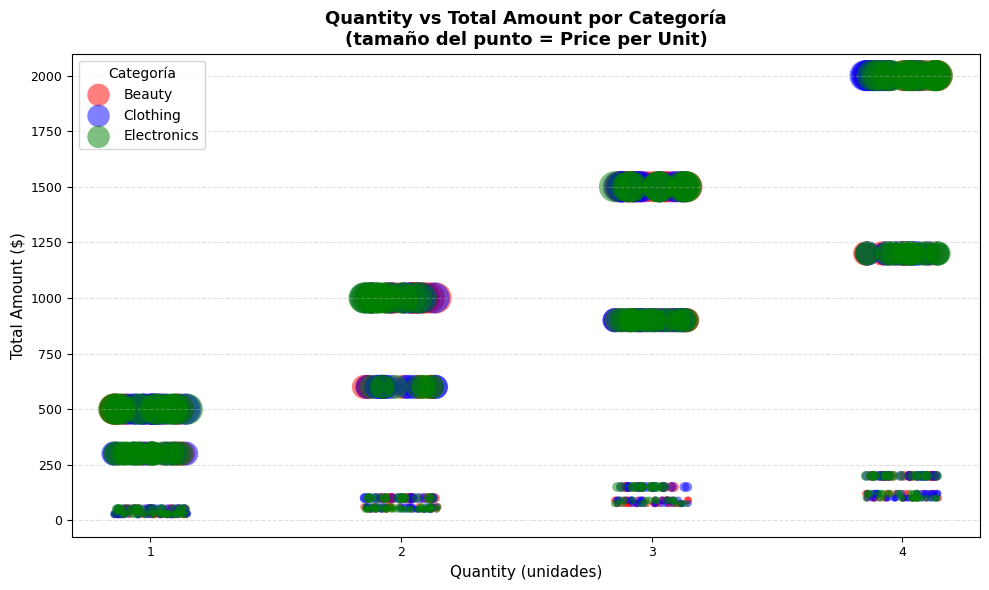

In [106]:
#Quantity vs Total Amount (Categoria) vs PRice per Unit

fig, ax = plt.subplots(figsize=(10, 6))

for cat, color in colores_categorias.items():
    subset = df[df['Product Category'] == cat]

    np.random.seed(42)
    jitter_x = np.random.uniform(-0.15, 0.15, size=len(subset))

    ax.scatter(subset['Quantity'] + jitter_x,
               subset['Total Amount'],
               label=cat,
               color=color,
               alpha=0.5,
               s=subset['Price per Unit'],  # tamaño del punto = precio unitario
               edgecolors='none')

ax.set_title('Quantity vs Total Amount por Categoría\n(tamaño del punto = Price per Unit)',
             fontweight='bold')
ax.set_xlabel('Quantity (unidades)')
ax.set_ylabel('Total Amount ($)')
ax.set_xticks([1, 2, 3, 4])
ax.legend(title='Categoría')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Ahora se puede ver claramente que los puntos grandes (precio unitario alto) se concentran en los montos altos del gráfico, mientras que los puntos pequeños (precio unitario bajo) se agrupan en la franja inferior. Esto confirma la conclusión anterior que el precio unitario es el factor determinante del Total Amount, más que la cantidad.